# Contact Map Visualization: Native vs SolubleMPNN Redesigns

Re-evaluation of exp5 (`random-3-bins`) on three structures (1QYS, 7BNY, 1UBQ) using the
HuggingFace checkpoint `timodonnell/LlamaFold-experiments` @ `exp5.ethereal-galaxy-3`.

For each structure, we generate contacts from:
1. The **native** sequence (wild-type).
2. **N** SolubleMPNN redesigns that preserve the backbone.

Ground-truth contacts come from the native backbone and are the same for every
redesign (MPNN only changes sequence). So this probes whether the model's
contact predictions follow the sequence (and, by extension, its implicit
structural reasoning) rather than just memorizing the native PDB.

In [1]:
# Config
PDB_IDS = ["1QYS", "7BNY", "1UBQ"]
N_REDESIGNS = 8
MPNN_TEMPERATURE = 0.2
MPNN_SEED = 42

CONTACT_DISTANCE_CUTOFF = 4.0     # bin_lt4 threshold
BIN_EDGES = [4.0, 12.0]           # must match training config
MAX_NEW_TOKENS = 3440
N_ROLLOUTS = 10
DEVICE = "cuda"

HF_REPO = "timodonnell/LlamaFold-experiments"
HF_SUBFOLDER = "exp5.ethereal-galaxy-3"
PROTEINMPNN_DIR = "/home/bizon/third_party/ProteinMPNN"
WORK_DIR = "./mpnn_work"

In [2]:
# Download checkpoint from HuggingFace. The repo stores a Trainer-style
# `checkpoint-NNNN/` subdir, so auto-descend into it if present.
from huggingface_hub import snapshot_download
from pathlib import Path

ckpt_root = snapshot_download(
    repo_id=HF_REPO,
    allow_patterns=[f"{HF_SUBFOLDER}/*"],
)
exp_dir = Path(ckpt_root) / HF_SUBFOLDER
ckpt_subdirs = sorted(exp_dir.glob("checkpoint-*"))
if (exp_dir / "config.json").exists():
    CHECKPOINT_PATH = exp_dir
elif ckpt_subdirs:
    CHECKPOINT_PATH = ckpt_subdirs[-1]  # last (highest step) checkpoint
else:
    raise FileNotFoundError(f"No checkpoint found under {exp_dir}")
print(f"Checkpoint cached at: {CHECKPOINT_PATH}")
assert (CHECKPOINT_PATH / "config.json").exists(), f"config.json not found in {CHECKPOINT_PATH}"

/home/bizon/git/llm-protein-experiments/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Fetching 15 files: 100%|██████████| 15/15 [00:00<00:00, 120989.54it/s]

Checkpoint cached at: /home/bizon/.cache/huggingface/hub/models--timodonnell--LlamaFold-experiments/snapshots/0d7f58337cf20bdafcb76f0436aa3befd42a06e6/exp5.ethereal-galaxy-3/checkpoint-125500


In [3]:
# Imports + helpers shared across structures
import os
import subprocess
import tempfile
import time
from collections import Counter

import numpy as np
import torch
from biotite.database import rcsb
from biotite.structure.io import pdbx, pdb as biotite_pdb
from biotite.structure import filter_amino_acids
from scipy.spatial import KDTree
from transformers import LlamaForCausalLM

from experiments.exp5_contact_prediction.src.data import AMINO_ACIDS, VALID_ATOMS, ATOM_NAMES
from experiments.exp5_contact_prediction.src.train import (
    create_tokenizer,
    parse_generated_contacts,
    check_atom_validity,
)

AA_3_TO_1 = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
    "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
    "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
    "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
}
AA_1_TO_3 = {v: k for k, v in AA_3_TO_1.items()}
NONSTANDARD_AA_MAP = {
    "MSE": "MET", "CSE": "CYS", "SEC": "CYS", "HYP": "PRO",
    "TPO": "THR", "SEP": "SER", "PTR": "TYR",
}

os.makedirs(WORK_DIR, exist_ok=True)

def assign_bin(dist):
    if dist < BIN_EDGES[0]:
        return "bin_lt4"
    elif dist < BIN_EDGES[1]:
        return "bin_4_12"
    else:
        return "bin_gt12"

def parse_pdb_structure(pdb_id):
    """Fetch + parse a PDB; return (chain_atoms, sequence, chain_id)."""
    path = rcsb.fetch(pdb_id, "cif", tempfile.gettempdir())
    cif = pdbx.CIFFile.read(path)
    atoms = pdbx.get_structure(cif.block, model=1)
    first_chain = atoms.chain_id[0]
    chain_atoms = atoms[
        (atoms.chain_id == first_chain)
        & filter_amino_acids(atoms)
        & (atoms.element != "H")
    ]
    unique_res = sorted(set(chain_atoms.res_id))
    sequence_raw = [chain_atoms[chain_atoms.res_id == rid].res_name[0] for rid in unique_res]
    aa_set = set(AMINO_ACIDS)
    sequence = []
    for aa in sequence_raw:
        if aa in aa_set:
            sequence.append(aa)
        elif aa in NONSTANDARD_AA_MAP:
            sequence.append(NONSTANDARD_AA_MAP[aa])
        else:
            raise ValueError(f"Unknown amino acid: {aa}")
    return chain_atoms, sequence, first_chain, unique_res

def compute_gt_contacts(chain_atoms, sequence, unique_res, rng_seed=42):
    """Reproduce exp5 GT-contact construction: closest valid atom pair per res pair < 4Å."""
    coords = chain_atoms.coord
    atom_names = chain_atoms.atom_name
    atom_res_ids = chain_atoms.res_id
    res_id_to_pos = {rid: i + 1 for i, rid in enumerate(unique_res)}
    all_known_atoms = set()
    for aa in VALID_ATOMS:
        all_known_atoms.update(VALID_ATOMS[aa])

    tree = KDTree(coords)
    close_pairs = tree.query_pairs(r=CONTACT_DISTANCE_CUTOFF)
    raw = []
    for i, j in close_pairs:
        ri, rj = atom_res_ids[i], atom_res_ids[j]
        pi, pj = res_id_to_pos.get(ri), res_id_to_pos.get(rj)
        if pi is None or pj is None or abs(pi - pj) < 2:
            continue
        ai, aj = str(atom_names[i]), str(atom_names[j])
        if ai not in all_known_atoms or aj not in all_known_atoms:
            continue
        aa_i, aa_j = sequence[pi - 1], sequence[pj - 1]
        if aa_i not in VALID_ATOMS or ai not in VALID_ATOMS[aa_i]:
            continue
        if aa_j not in VALID_ATOMS or aj not in VALID_ATOMS[aa_j]:
            continue
        d = float(np.linalg.norm(coords[i] - coords[j]))
        if pi > pj:
            raw.append((pj, pi, aj, ai, d))
        else:
            raw.append((pi, pj, ai, aj, d))

    best = {}
    for c in raw:
        key = (c[0], c[1])
        if key not in best or c[4] < best[key][4]:
            best[key] = c
    rng = np.random.RandomState(rng_seed)
    items = list(best.values())
    rng.shuffle(items)
    return [(False, p1, p2, a1, a2, assign_bin(d)) for p1, p2, a1, a2, d in items]

def build_prompt(sequence):
    seq_tokens = " ".join(f"<{aa}>" for aa in sequence)
    return f"<random-3-bins> <begin_sequence> {seq_tokens} <begin_contacts>"

def contacts_to_matrix(contacts, seq_len):
    m = np.zeros((seq_len, seq_len), dtype=np.float32)
    for c in contacts:
        p1, p2 = c[1], c[2]
        if 1 <= p1 <= seq_len and 1 <= p2 <= seq_len:
            m[p1 - 1, p2 - 1] = 1
            m[p2 - 1, p1 - 1] = 1
    return m

def rollout_freq_matrix(rollouts, seq_len):
    freq = np.zeros((seq_len, seq_len), dtype=np.float32)
    for contacts in rollouts:
        lt4 = [c for c in contacts if c[5] == "bin_lt4"]
        freq += contacts_to_matrix(lt4, seq_len)
    return freq / max(len(rollouts), 1)

def eval_consensus(freq, gt_pair_set, seq_len, threshold=0.5):
    pred = set()
    for i in range(seq_len):
        for j in range(i + 1, seq_len):
            if freq[i, j] > threshold:
                pred.add((i + 1, j + 1))
    n_correct = len(pred & gt_pair_set)
    n_pred = len(pred)
    return {
        "n_pred": n_pred,
        "n_correct": n_correct,
        "precision": n_correct / n_pred if n_pred else 0.0,
        "recall": n_correct / len(gt_pair_set) if gt_pair_set else 0.0,
    }

def seq_identity(a, b):
    assert len(a) == len(b), f"length mismatch {len(a)} vs {len(b)}"
    return sum(1 for x, y in zip(a, b) if x == y) / len(a)

print("helpers ready")

helpers ready


In [4]:
# Load model + tokenizer (once, reused across structures)
print(f"Loading checkpoint: {CHECKPOINT_PATH}")
tokenizer = create_tokenizer()
model = LlamaForCausalLM.from_pretrained(str(CHECKPOINT_PATH), torch_dtype=torch.bfloat16)
model = model.to(DEVICE).eval()
end_token_id = tokenizer.convert_tokens_to_ids("<end>")
print(f"Model loaded: {sum(p.numel() for p in model.parameters()):,} parameters")

def run_generation(prompt, do_sample=False):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=8192)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    gen_kwargs = dict(
        max_new_tokens=MAX_NEW_TOKENS,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=end_token_id,
    )
    if do_sample:
        gen_kwargs.update(do_sample=True, temperature=1.0, top_k=0)
    else:
        gen_kwargs.update(do_sample=False)
    t0 = time.time()
    with torch.no_grad():
        out = model.generate(**inputs, **gen_kwargs)
    elapsed = time.time() - t0
    gen_ids = out[0][inputs["input_ids"].shape[1]:]
    gen_text = tokenizer.decode(gen_ids, skip_special_tokens=False)
    contacts, valid, plddt = parse_generated_contacts(gen_text.split())
    return contacts, valid, plddt, elapsed

Loading checkpoint: /home/bizon/.cache/huggingface/hub/models--timodonnell--LlamaFold-experiments/snapshots/0d7f58337cf20bdafcb76f0436aa3befd42a06e6/exp5.ethereal-galaxy-3/checkpoint-125500


Loading weights:   0%|          | 0/147 [00:00<?, ?it/s]

Loading weights:   1%|          | 1/147 [00:00<00:00, 22192.08it/s, Materializing param=lm_head.weight]

Loading weights:   1%|          | 1/147 [00:00<00:00, 3030.57it/s, Materializing param=lm_head.weight] 

Loading weights:   1%|▏         | 2/147 [00:00<00:01, 99.97it/s, Materializing param=model.embed_tokens.weight]

...

Loading weights:  99%|█████████▉| 146/147 [00:00<00:00, 485.34it/s, Materializing param=model.layers.15.self_attn.v_proj.weight]

Loading weights: 100%|██████████| 147/147 [00:00<00:00, 485.34it/s, Materializing param=model.norm.weight]                      

Loading weights: 100%|██████████| 147/147 [00:00<00:00, 485.34it/s, Materializing param=model.norm.weight]

Loading weights: 100%|██████████| 147/147 [00:00<00:00, 851.80it/s, Materializing param=model.norm.weight]

Model loaded: 984,528,896 parameters


In [5]:
# Parse every PDB, compute GT contacts, and write a PDB file for ProteinMPNN input.
# Each struct dict holds everything we need downstream.
structures = {}
for pdb_id in PDB_IDS:
    chain_atoms, sequence, chain_id, unique_res = parse_pdb_structure(pdb_id)
    gt_contacts = compute_gt_contacts(chain_atoms, sequence, unique_res)
    gt_pair_set = {(c[1], c[2]) for c in gt_contacts}

    pdb_path = os.path.join(WORK_DIR, f"{pdb_id}.pdb")
    pdb_file = biotite_pdb.PDBFile()
    pdb_file.set_structure(chain_atoms)
    pdb_file.write(pdb_path)

    structures[pdb_id] = {
        "sequence": sequence,
        "seq_len": len(sequence),
        "chain_id": chain_id,
        "gt_contacts": gt_contacts,
        "gt_pair_set": gt_pair_set,
        "pdb_path": pdb_path,
    }
    print(f"{pdb_id}: {len(sequence)} residues, chain {chain_id}, "
          f"{len(gt_pair_set)} GT contacts, pdb at {pdb_path}")

1QYS: 92 residues, chain A, 257 GT contacts, pdb at ./mpnn_work/1QYS.pdb
7BNY: 132 residues, chain A, 347 GT contacts, pdb at ./mpnn_work/7BNY.pdb


1UBQ: 76 residues, chain A, 194 GT contacts, pdb at ./mpnn_work/1UBQ.pdb


In [6]:
# Generate SolubleMPNN redesigns for each structure.
# Runs protein_mpnn_run.py as a subprocess with --use_soluble_model.
# Output FASTA headers contain a `score=` field; seqs beyond the native are the redesigns.

def run_soluble_mpnn(pdb_path, out_dir, num_seqs, temperature, seed):
    os.makedirs(out_dir, exist_ok=True)
    cmd = [
        "python", os.path.join(PROTEINMPNN_DIR, "protein_mpnn_run.py"),
        "--pdb_path", pdb_path,
        "--out_folder", out_dir,
        "--num_seq_per_target", str(num_seqs),
        "--batch_size", "1",
        "--sampling_temp", str(temperature),
        "--seed", str(seed),
        "--use_soluble_model",
    ]
    env = dict(os.environ)
    env["PYTHONPATH"] = PROTEINMPNN_DIR + os.pathsep + env.get("PYTHONPATH", "")
    print("  running:", " ".join(cmd))
    subprocess.run(cmd, check=True, env=env)
    # protein_mpnn_run writes seqs/<stem>.fa
    stem = os.path.splitext(os.path.basename(pdb_path))[0]
    fasta_path = os.path.join(out_dir, "seqs", f"{stem}.fa")
    assert os.path.exists(fasta_path), f"Expected MPNN output at {fasta_path}"
    return fasta_path

def parse_mpnn_fasta(fasta_path):
    """Return list of (header, sequence). First entry is native; rest are redesigns."""
    entries = []
    header, seq_lines = None, []
    with open(fasta_path) as f:
        for line in f:
            line = line.rstrip()
            if line.startswith(">"):
                if header is not None:
                    entries.append((header, "".join(seq_lines)))
                header, seq_lines = line[1:], []
            else:
                seq_lines.append(line)
        if header is not None:
            entries.append((header, "".join(seq_lines)))
    return entries

for pdb_id, info in structures.items():
    print(f"\n=== SolubleMPNN for {pdb_id} ===")
    out_dir = os.path.join(WORK_DIR, f"mpnn_{pdb_id}")
    fasta = run_soluble_mpnn(info["pdb_path"], out_dir, N_REDESIGNS, MPNN_TEMPERATURE, MPNN_SEED)
    entries = parse_mpnn_fasta(fasta)
    # Entry 0 is the native (from ProteinMPNN); remaining are the N_REDESIGNS samples.
    native_seq_1letter = entries[0][1]
    redesigns_1letter = [seq for _, seq in entries[1:1 + N_REDESIGNS]]

    # Drop any chain separators (`/` or `:`) ProteinMPNN may insert
    def clean(s): return s.replace("/", "").replace(":", "")
    native_seq_1letter = clean(native_seq_1letter)
    redesigns_1letter = [clean(s) for s in redesigns_1letter]

    # Sanity: native from MPNN should match our parsed sequence
    ours_1 = "".join(AA_3_TO_1[aa] for aa in info["sequence"])
    assert len(native_seq_1letter) == len(ours_1), (
        f"Length mismatch for {pdb_id}: MPNN={len(native_seq_1letter)} vs ours={len(ours_1)}")
    if native_seq_1letter != ours_1:
        print(f"  WARNING: MPNN native differs from parsed native (id={seq_identity(native_seq_1letter, ours_1):.2f})")

    # Convert redesigns to 3-letter-list form (model input format)
    redesigns_3letter = [[AA_1_TO_3[c] for c in s] for s in redesigns_1letter]
    info["native_1letter"] = ours_1
    info["redesigns_1letter"] = redesigns_1letter
    info["redesigns_3letter"] = redesigns_3letter
    print(f"  got {len(redesigns_3letter)} redesigns")
    for i, s in enumerate(redesigns_1letter):
        print(f"    R{i}: identity={seq_identity(s, ours_1):.2%}  {s[:60]}{'...' if len(s) > 60 else ''}")


=== SolubleMPNN for 1QYS ===
  running: python /home/bizon/third_party/ProteinMPNN/protein_mpnn_run.py --pdb_path ./mpnn_work/1QYS.pdb --out_folder ./mpnn_work/mpnn_1QYS --num_seq_per_target 8 --batch_size 1 --sampling_temp 0.2 --seed 42 --use_soluble_model


Using ProteinMPNN trained on soluble proteins only!
----------------------------------------
chain_id_jsonl is NOT loaded
----------------------------------------
fixed_positions_jsonl is NOT loaded
----------------------------------------
pssm_jsonl is NOT loaded
----------------------------------------
omit_AA_jsonl is NOT loaded
----------------------------------------
bias_AA_jsonl is NOT loaded
----------------------------------------
tied_positions_jsonl is NOT loaded
----------------------------------------
bias by residue dictionary is not loaded, or not provided
----------------------------------------
----------------------------------------
Number of edges: 48
Training noise level: 0.2A
Generating sequences for: 1QYS
8 sequences of length 92 generated in 2.1754 seconds


  got 8 redesigns
    R0: identity=38.04%  MLKITVTIEKGDEKIVIEKEVDSEEELEKFLKELEELIREKDPEIVTVSIEAESKEEAEK...
    R1: identity=43.48%  MIKITVVIKDNNKEIVIEKEVESEEELEKVLEEIKKIIEKENPKEVEVSVEAETPEKAEE...
    R2: identity=45.65%  MIQIKVTIEKDGEKIVLEKTVESEEELEKVLKDIEEIIKKLNPEEVTVSITAETPEEAKK...
    R3: identity=38.04%  MLKITVVIEKGGERTVEEYEVESREELEEVLEELKERVRELDPPRVTVSVEAETREEAEE...
    R4: identity=43.48%  MLKITVVIEKGGKKEVIEKEVESEEELEKVLEELEEKIKKLDPETVTISIEAPSPEEAEK...
    R5: identity=43.48%  MLKVTVTIKKGDETIVLEYEVSSEEELKKLLEELKEKIKELNPDTVTVSVEAESKEEAEK...
    R6: identity=43.48%  MIKIEVIIKKEGEEIKLIYEVKDEEELEKVLEEIKEIVKKLDPEEVEISVEAKTKEEAEK...
    R7: identity=38.04%  MIKIRVVIKKDGEEIVLEYEVESKEELKEVLEKIKELIRELDPPEVEISVEAESKEEAEE...

=== SolubleMPNN for 7BNY ===
  running: python /home/bizon/third_party/ProteinMPNN/protein_mpnn_run.py --pdb_path ./mpnn_work/7BNY.pdb --out_folder ./mpnn_work/mpnn_7BNY --num_seq_per_target 8 --batch_size 1 --sampling_temp 0.2 --seed 42 --use_soluble_model


Using ProteinMPNN trained on soluble proteins only!
----------------------------------------
chain_id_jsonl is NOT loaded
----------------------------------------
fixed_positions_jsonl is NOT loaded
----------------------------------------
pssm_jsonl is NOT loaded
----------------------------------------
omit_AA_jsonl is NOT loaded
----------------------------------------
bias_AA_jsonl is NOT loaded
----------------------------------------
tied_positions_jsonl is NOT loaded
----------------------------------------
bias by residue dictionary is not loaded, or not provided
----------------------------------------
----------------------------------------
Number of edges: 48
Training noise level: 0.2A
Generating sequences for: 7BNY
8 sequences of length 132 generated in 3.0225 seconds


  got 8 redesigns
    R0: identity=44.70%  SVPVLRIRLTFTHDGLHADIYYQGQLMATTYAPVILRSEEKQIEFLKNGYYEEQDESDPS...
    R1: identity=37.88%  SMPVLRIKLTFSHEGLHAEIYYKGQLLATSKAPVILKSEEKQINFLKNGYVEENDESDPE...
    R2: identity=43.94%  MTPILEIKLTFTHEGLHAEIYYQGQLKAETEAPVVLRSKEKQIEFLKNGHYEKQDEVDPE...
    R3: identity=39.39%  STPKLVIKLTFSDEGLKADFYYEGQLMATSKAPVILKSKEKQINFLKNGYIETQDESDPN...
    R4: identity=40.15%  MIPKLVIKLTFTHEGLHAEIYKDGQLMATSKAPVILKSEEKQIEFLRKGYYEENDESDPD...
    R5: identity=41.67%  SMPRLVIKLTFTHEGLFAEIYYDGQLYAKTKAPVILKSKEKQIEFLRNGYIEKNDKSDPK...
    R6: identity=41.67%  MTPVLRIKLTFTHEGLHAEVYLDGQLWATSKAPVILKSEEKQIEFLKNGYIEELDESDPE...
    R7: identity=40.15%  NIPRLVIKLTFTHEGLHAEIYYDGQLFAKTEAPVILRTKEKQIKFLREGRIEKQDESNPE...

=== SolubleMPNN for 1UBQ ===
  running: python /home/bizon/third_party/ProteinMPNN/protein_mpnn_run.py --pdb_path ./mpnn_work/1UBQ.pdb --out_folder ./mpnn_work/mpnn_1UBQ --num_seq_per_target 8 --batch_size 1 --sampling_temp 0.2 --seed 42 --use_soluble_model


Using ProteinMPNN trained on soluble proteins only!
----------------------------------------
chain_id_jsonl is NOT loaded
----------------------------------------
fixed_positions_jsonl is NOT loaded
----------------------------------------
pssm_jsonl is NOT loaded
----------------------------------------
omit_AA_jsonl is NOT loaded
----------------------------------------
bias_AA_jsonl is NOT loaded
----------------------------------------
tied_positions_jsonl is NOT loaded
----------------------------------------
bias by residue dictionary is not loaded, or not provided
----------------------------------------
----------------------------------------
Number of edges: 48
Training noise level: 0.2A
Generating sequences for: 1UBQ
8 sequences of length 76 generated in 1.8317 seconds


  got 8 redesigns
    R0: identity=60.53%  MKIFVKLPDGKTIELEVEPSDTIEQVKKKIEEKIGIPPEEQVLIYNGKELKDDKTLADYN...
    R1: identity=64.47%  MKIFVKFEDGRTLELEVEPSDTIAEVKEKIQEKVGIPPEEQVLIFNGKELEDDKTLSDYN...
    R2: identity=61.84%  MKIFVKLEDGKTIELEVEKSDTIKEVKEKIEEKVGIPPEEQVLIYNGKELEDDKTLEDYD...
    R3: identity=52.63%  MKIFVEFEDGRTLELEVDETDTIKEVKEKIEEKTGIPPEKQKLIFKGKVLEDEQTLKDYD...
    R4: identity=61.84%  MKIFVKLEDGKTIELEVKPEDTIKEVKKKIEEKTGIPPEEQVLIFNGKELEDEKTLSDYG...
    R5: identity=61.84%  MKIFVKLENGETIELEVEPSDTIAEVKEKIQEKTGIPPEEQVLIFNGKELKDDQTLADYD...
    R6: identity=60.53%  MKIFVKFSDGETLELEVEPSDTIAEVKAKIEEKKGIPPEEQRLIYNGKILEDEKTLADYN...
    R7: identity=60.53%  MKIFVKLENGETIELEVEPSDTIAEVKAKIEEKTGIPPEEQVLIYKGKELKDEDTLADYD...


In [7]:
# Run model on native + each redesign, collecting N_ROLLOUTS samples per sequence.
# Structure of results:
#   info["variants"] = [
#       {"label": "native"|"R0"|..., "sequence": [3letter], "identity": 1.0 or frac,
#        "greedy_contacts": [...], "greedy_plddt": tok, "greedy_time": s,
#        "rollouts": [[...], ...], "rollout_plddts": [...], "rollout_times": [...]},
#       ...
#   ]

def run_model_for_sequence(sequence_3letter):
    prompt = build_prompt(sequence_3letter)
    greedy, valid_g, plddt_g, t_g = run_generation(prompt, do_sample=False)
    rollouts, plddts, times = [], [], []
    for _ in range(N_ROLLOUTS):
        c, _, p, t = run_generation(prompt, do_sample=True)
        rollouts.append(c)
        plddts.append(p)
        times.append(t)
    return {
        "greedy_contacts": greedy,
        "greedy_valid": valid_g,
        "greedy_plddt": plddt_g,
        "greedy_time": t_g,
        "rollouts": rollouts,
        "rollout_plddts": plddts,
        "rollout_times": times,
    }

for pdb_id, info in structures.items():
    print(f"\n=== {pdb_id} ({info['seq_len']} residues) ===")
    variants = []
    # Native
    t0 = time.time()
    print("  [native]  running...", flush=True)
    res = run_model_for_sequence(info["sequence"])
    print(f"  [native]  done in {time.time() - t0:.1f}s (greedy {res['greedy_time']:.1f}s, rollout avg {np.mean(res['rollout_times']):.1f}s)")
    variants.append({
        "label": "native",
        "sequence": info["sequence"],
        "sequence_1letter": info["native_1letter"],
        "identity": 1.0,
        **res,
    })
    # Redesigns
    for i, seq3 in enumerate(info["redesigns_3letter"]):
        t0 = time.time()
        print(f"  [R{i}]      running...", flush=True)
        res = run_model_for_sequence(seq3)
        id_frac = seq_identity(info["redesigns_1letter"][i], info["native_1letter"])
        print(f"  [R{i}]      done in {time.time() - t0:.1f}s (id={id_frac:.2%}, rollout avg {np.mean(res['rollout_times']):.1f}s)")
        variants.append({
            "label": f"R{i}",
            "sequence": seq3,
            "sequence_1letter": info["redesigns_1letter"][i],
            "identity": id_frac,
            **res,
        })
    info["variants"] = variants


=== 1QYS (92 residues) ===
  [native]  running...


  [native]  done in 205.7s (greedy 5.0s, rollout avg 20.1s)
  [R0]      running...


  [R0]      done in 212.7s (id=38.04%, rollout avg 20.9s)
  [R1]      running...


  [R1]      done in 229.7s (id=43.48%, rollout avg 22.6s)
  [R2]      running...


  [R2]      done in 220.6s (id=45.65%, rollout avg 21.7s)
  [R3]      running...


...

  [R3]      done in 181.9s (id=52.63%, rollout avg 17.8s)
  [R4]      running...


  [R4]      done in 182.9s (id=61.84%, rollout avg 18.0s)
  [R5]      running...


  [R5]      done in 182.2s (id=61.84%, rollout avg 17.9s)
  [R6]      running...


  [R6]      done in 184.5s (id=60.53%, rollout avg 18.1s)
  [R7]      running...


  [R7]      done in 183.0s (id=60.53%, rollout avg 18.0s)


In [8]:
# Compute per-variant accuracy metrics (consensus against native GT contacts).
for pdb_id, info in structures.items():
    seq_len = info["seq_len"]
    gt_pair_set = info["gt_pair_set"]
    for v in info["variants"]:
        freq = rollout_freq_matrix(v["rollouts"], seq_len)
        v["freq_matrix"] = freq
        v["consensus"] = eval_consensus(freq, gt_pair_set, seq_len, threshold=0.5)
        # Greedy accuracy (bin_lt4 residue pairs)
        g_lt4 = {(min(c[1], c[2]), max(c[1], c[2])) for c in v["greedy_contacts"] if c[5] == "bin_lt4"}
        v["greedy"] = {
            "n_pred": len(g_lt4),
            "n_correct": len(g_lt4 & gt_pair_set),
            "precision": len(g_lt4 & gt_pair_set) / len(g_lt4) if g_lt4 else 0.0,
            "recall": len(g_lt4 & gt_pair_set) / len(gt_pair_set) if gt_pair_set else 0.0,
        }

# Summary table
print(f"{'PDB':<6} {'Variant':<10} {'Identity':>9}  |  "
      f"{'Greedy P':>8} {'Greedy R':>8}  |  {'Cons P':>7} {'Cons R':>7}  {'NPred':>5}")
print("-" * 92)
for pdb_id, info in structures.items():
    for v in info["variants"]:
        g = v["greedy"]; c = v["consensus"]
        print(f"{pdb_id:<6} {v['label']:<10} {v['identity']:>8.2%}  |  "
              f"{g['precision']:>7.1%} {g['recall']:>7.1%}  |  "
              f"{c['precision']:>6.1%} {c['recall']:>6.1%}  {c['n_pred']:>5d}")

PDB    Variant     Identity  |  Greedy P Greedy R  |   Cons P  Cons R  NPred
--------------------------------------------------------------------------------------------
1QYS   native      100.00%  |   100.0%   15.2%  |   94.0%  54.9%    150
1QYS   R0           38.04%  |    78.0%   12.5%  |   95.1%  60.7%    164
1QYS   R1           43.48%  |    75.0%   11.7%  |   88.4%  65.0%    189
1QYS   R2           45.65%  |    71.8%   10.9%  |   91.1%  67.7%    191
1QYS   R3           38.04%  |    71.4%    9.7%  |   88.0%  65.8%    192
1QYS   R4           43.48%  |    75.7%   10.9%  |   90.0%  66.5%    190
1QYS   R5           43.48%  |    69.4%    9.7%  |   88.3%  64.6%    188
1QYS   R6           43.48%  |    64.7%    8.6%  |   94.4%  58.8%    160
1QYS   R7           38.04%  |    69.2%   10.5%  |   90.5%  66.9%    190
7BNY   native      100.00%  |    81.5%    6.3%  |   69.8%  25.9%    129
7BNY   R0           44.70%  |    49.1%    7.8%  |   77.0%  36.6%    165
7BNY   R1           37.88%  |    59.3%

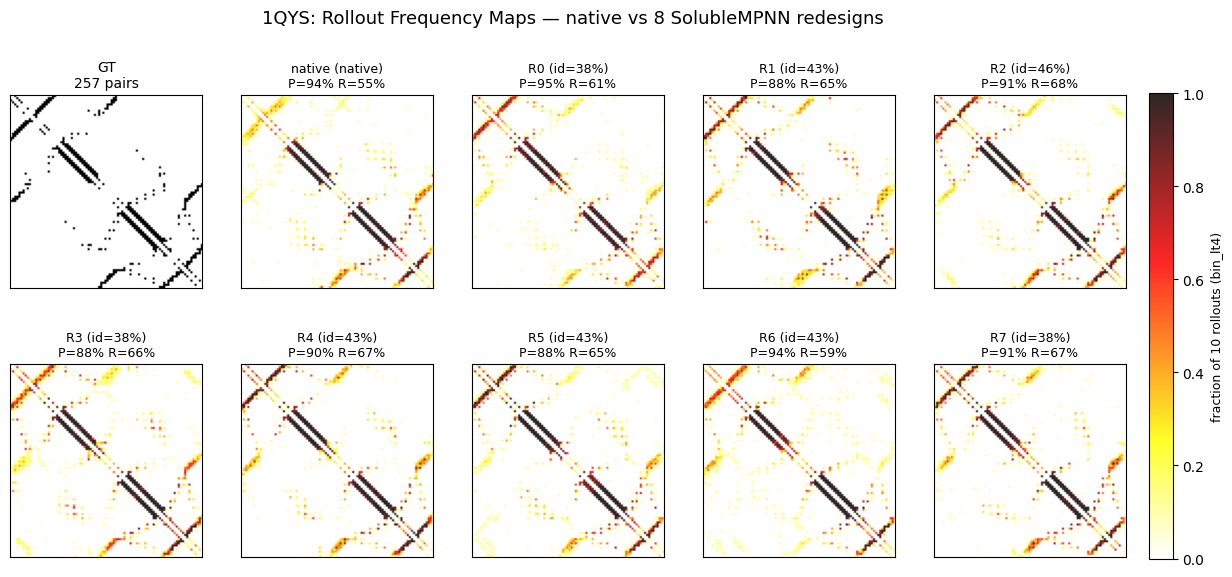

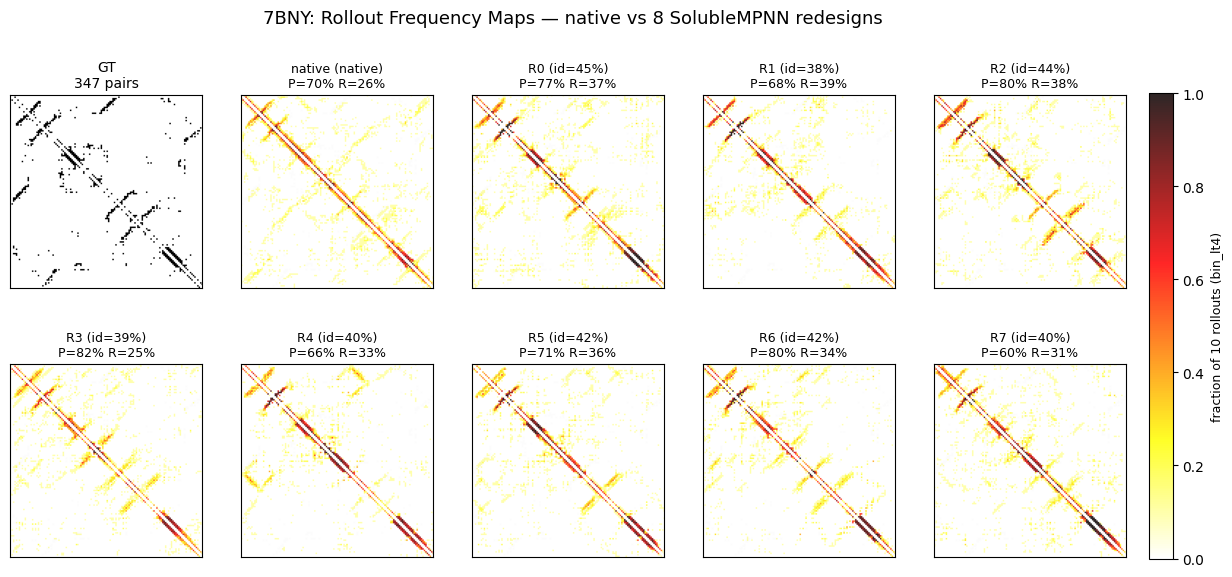

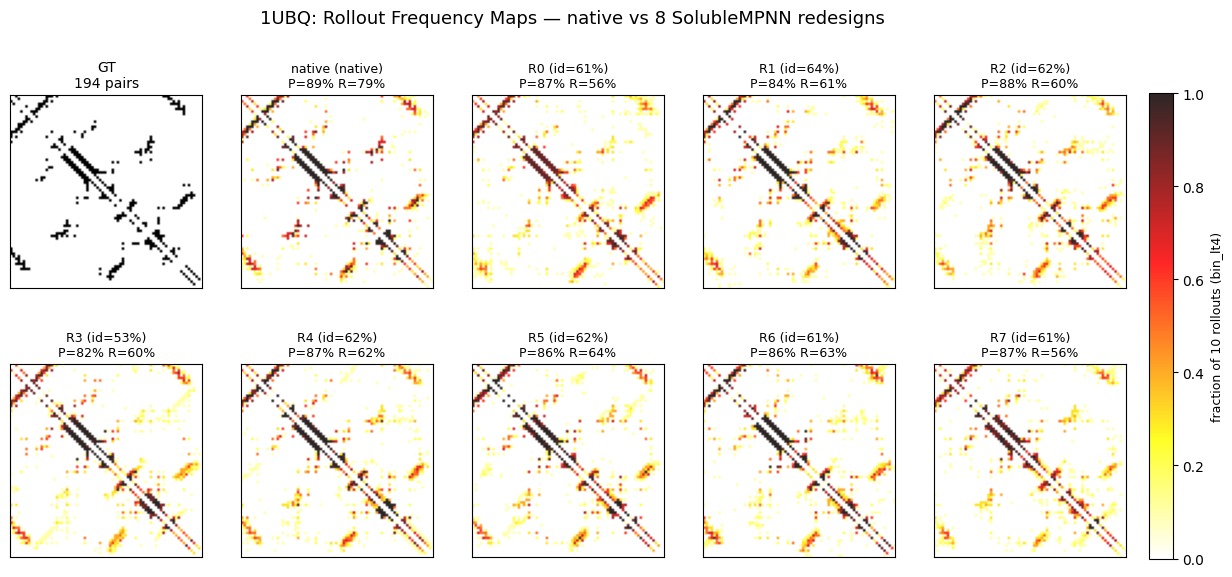

In [9]:
# Grid of rollout-frequency contact maps: rows = variants, cols = PDBs (or vice versa).
# One figure per PDB; grid of (1 + N_REDESIGNS) panels. GT contacts overlaid as contours.
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

for pdb_id, info in structures.items():
    seq_len = info["seq_len"]
    gt_matrix = contacts_to_matrix(info["gt_contacts"], seq_len)
    gt_pair_set = info["gt_pair_set"]

    n_panels = 1 + 1 + N_REDESIGNS  # GT + native + redesigns
    n_cols = 5
    n_rows = (n_panels + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.0 * n_cols, 3.2 * n_rows))
    axes = np.atleast_2d(axes).ravel()

    # GT panel
    axes[0].imshow(gt_matrix, cmap="Greys", vmin=0, vmax=1, origin="upper", aspect="equal")
    axes[0].set_title(f"GT\n{len(gt_pair_set)} pairs", fontsize=10)
    axes[0].set_xticks([]); axes[0].set_yticks([])

    # Variants: each shows rollout frequency heatmap; GT contacts as translucent gray overlay.
    im = None
    for i, v in enumerate(info["variants"]):
        ax = axes[i + 1]
        freq = v["freq_matrix"]
        # gray overlay of GT (faint)
        ax.imshow(np.where(gt_matrix > 0, 0.3, 0.0),
                  cmap="Greys", vmin=0, vmax=1, origin="upper", aspect="equal", alpha=0.35)
        im = ax.imshow(freq, cmap="hot_r", vmin=0, vmax=1, origin="upper", aspect="equal", alpha=0.85)
        c = v["consensus"]
        label = v["label"]
        id_str = f"id={v['identity']:.0%}" if label != "native" else "native"
        ax.set_title(f"{label} ({id_str})\nP={c['precision']:.0%} R={c['recall']:.0%}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

    # Hide unused
    for k in range(n_panels, len(axes)):
        axes[k].axis("off")

    # Colorbar
    if im is not None:
        cbar = fig.colorbar(im, ax=axes[:n_panels].tolist(), fraction=0.02, pad=0.02)
        cbar.set_label(f"fraction of {N_ROLLOUTS} rollouts (bin_lt4)", fontsize=9)
    fig.suptitle(f"{pdb_id}: Rollout Frequency Maps — native vs {N_REDESIGNS} SolubleMPNN redesigns",
                 fontsize=13, y=0.99)
    plt.show()

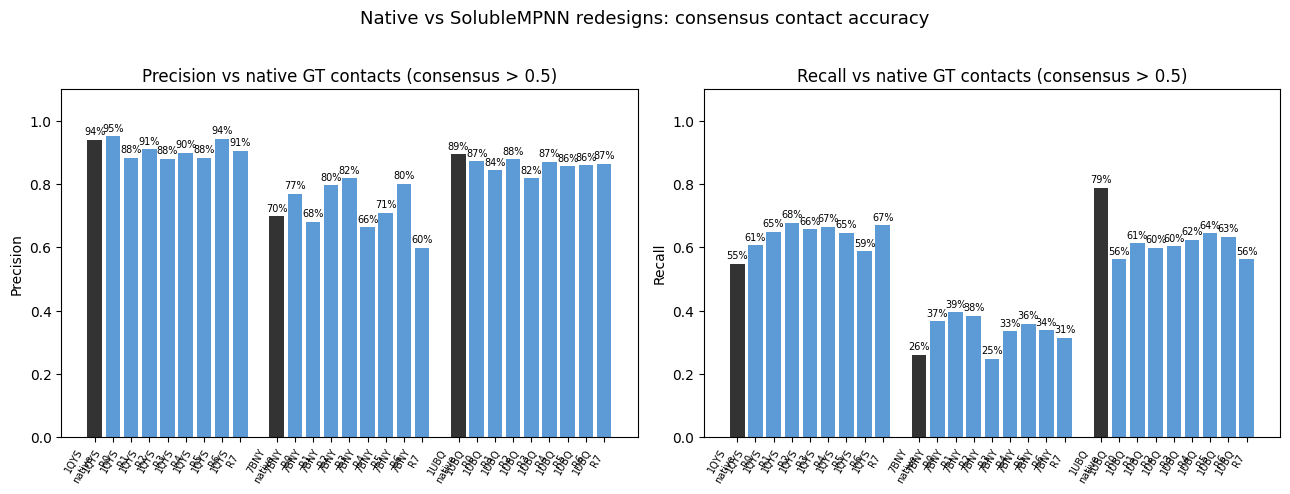

In [10]:
# Precision/recall of consensus contacts, native vs redesigns, per PDB.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for ax, metric, metric_label in zip(axes, ["precision", "recall"], ["Precision", "Recall"]):
    x_offset = 0
    xticks, xlabels = [], []
    for pdb_id, info in structures.items():
        vals = [v["consensus"][metric] for v in info["variants"]]
        labels = [v["label"] for v in info["variants"]]
        colors = ["#333333"] + ["#5C9BD5"] * (len(vals) - 1)
        positions = np.arange(len(vals)) + x_offset
        ax.bar(positions, vals, color=colors)
        for pos, val in zip(positions, vals):
            ax.text(pos, val + 0.01, f"{val:.0%}", ha="center", va="bottom", fontsize=7)
        xticks.extend(positions)
        xlabels.extend([f"{pdb_id}\n{l}" for l in labels])
        x_offset += len(vals) + 1

    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels, rotation=60, ha="right", fontsize=7)
    ax.set_ylabel(metric_label)
    ax.set_title(f"{metric_label} vs native GT contacts (consensus > 0.5)")
    ax.set_ylim(0, 1.1)

fig.suptitle("Native vs SolubleMPNN redesigns: consensus contact accuracy", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

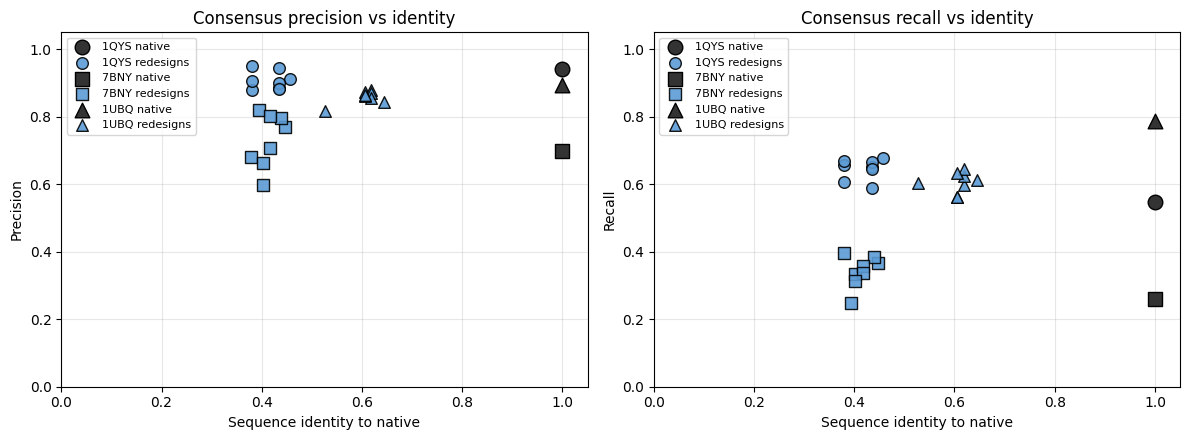

In [11]:
# Scatter: consensus precision/recall vs sequence identity to native.
# Redesigns cluster at ~30-50% identity; native is at 1.0. Does precision fall off?
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
markers = {"1QYS": "o", "7BNY": "s", "1UBQ": "^"}
default_marker = "D"

for ax, metric, metric_label in zip(axes, ["precision", "recall"], ["Precision", "Recall"]):
    for pdb_id, info in structures.items():
        xs = [v["identity"] for v in info["variants"]]
        ys = [v["consensus"][metric] for v in info["variants"]]
        m = markers.get(pdb_id, default_marker)
        ax.scatter(xs[0], ys[0], s=110, marker=m, facecolors="#333333", edgecolors="black",
                   label=f"{pdb_id} native", zorder=3)
        ax.scatter(xs[1:], ys[1:], s=70, marker=m, facecolors="#5C9BD5", edgecolors="black",
                   label=f"{pdb_id} redesigns", zorder=2, alpha=0.9)
    ax.set_xlabel("Sequence identity to native")
    ax.set_ylabel(metric_label)
    ax.set_title(f"Consensus {metric_label.lower()} vs identity")
    ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()

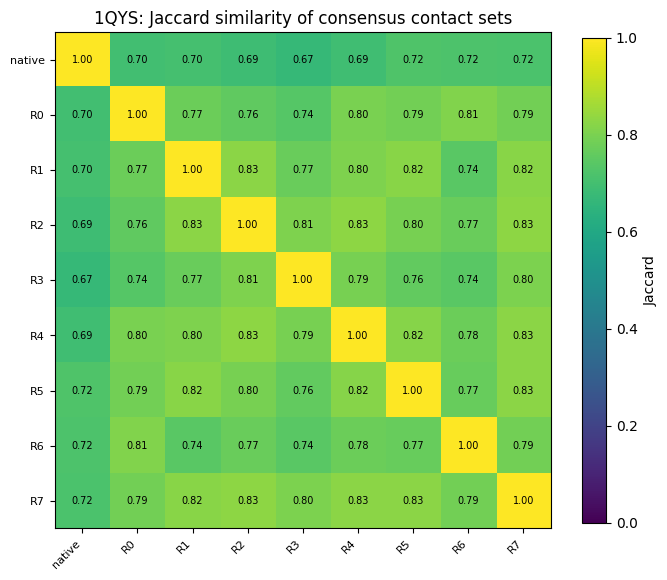

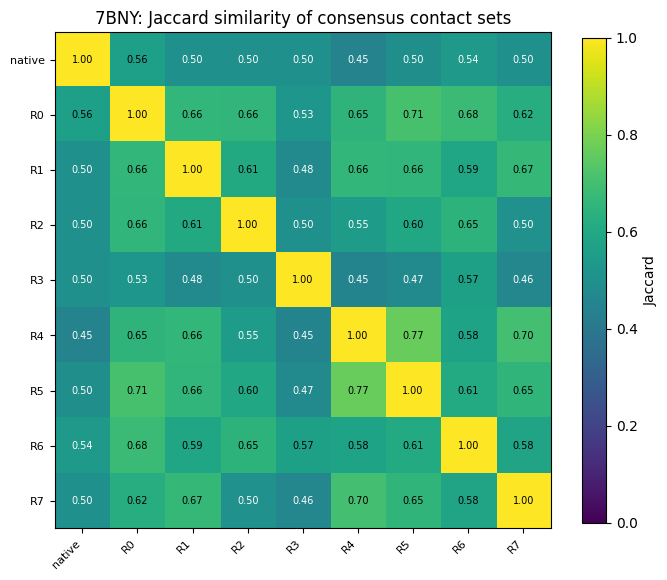

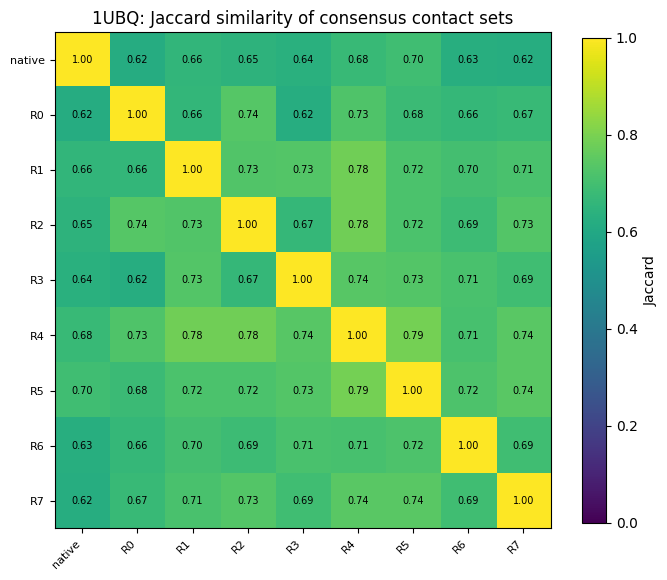

In [12]:
# Jaccard similarity between rollout-consensus contact sets across variants.
# High values = model predicts similar contacts regardless of sequence (memorizing backbone?).
def consensus_pairs(freq, seq_len, threshold=0.5):
    return {
        (i + 1, j + 1)
        for i in range(seq_len)
        for j in range(i + 1, seq_len)
        if freq[i, j] > threshold
    }

for pdb_id, info in structures.items():
    variants = info["variants"]
    seq_len = info["seq_len"]
    pairs = [consensus_pairs(v["freq_matrix"], seq_len) for v in variants]
    labels = [v["label"] for v in variants]
    n = len(variants)
    mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            a, b = pairs[i], pairs[j]
            mat[i, j] = len(a & b) / len(a | b) if (a | b) else 1.0

    fig, ax = plt.subplots(figsize=(0.55 * n + 2, 0.55 * n + 1.5))
    im = ax.imshow(mat, cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{mat[i,j]:.2f}", ha="center", va="center",
                    color="white" if mat[i,j] < 0.55 else "black", fontsize=7)
    plt.colorbar(im, ax=ax, shrink=0.8, label="Jaccard")
    ax.set_title(f"{pdb_id}: Jaccard similarity of consensus contact sets")
    plt.tight_layout()
    plt.show()

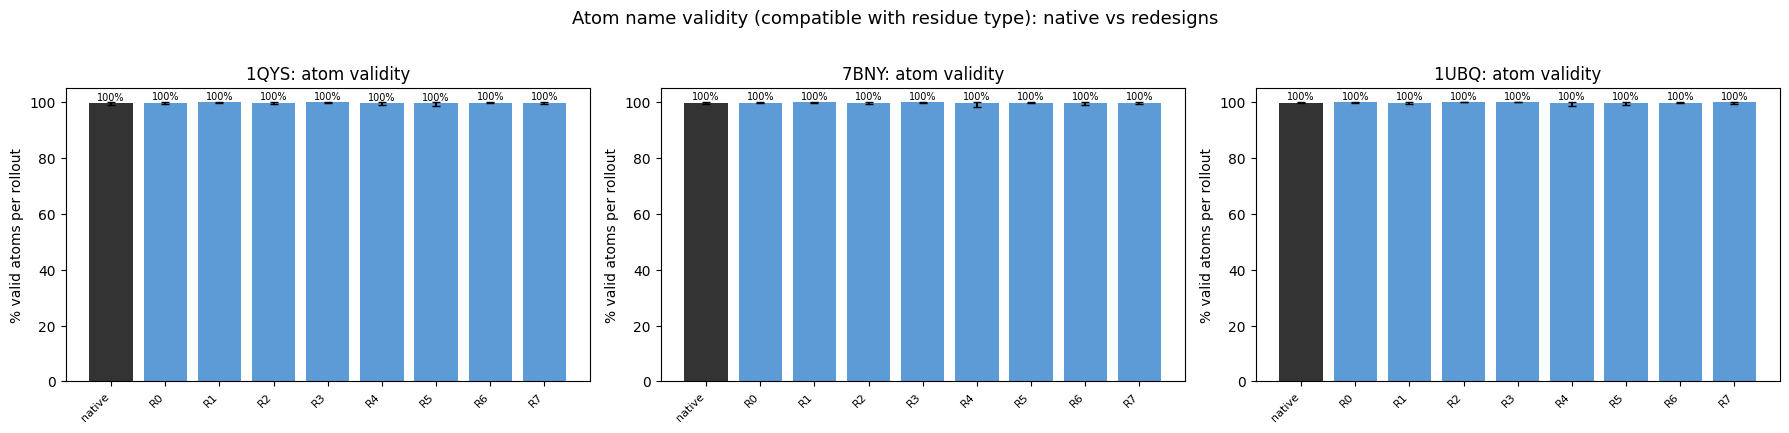

In [13]:
# Atom-level validity: are generated atom names compatible with the (redesigned) amino acid?
# Redesigns change residue identities, so the valid-atom set per position changes.
# This checks whether the model adapts.
fig, axes = plt.subplots(1, len(structures), figsize=(6 * len(structures), 4.2), squeeze=False)
axes = axes[0]
for ax, (pdb_id, info) in zip(axes, structures.items()):
    labels, means, mins, maxs = [], [], [], []
    for v in info["variants"]:
        pcts = []
        for r in v["rollouts"]:
            nv, nt = check_atom_validity(r, v["sequence"])
            pcts.append(100 * nv / nt if nt else 0)
        labels.append(v["label"])
        means.append(np.mean(pcts))
        mins.append(np.min(pcts))
        maxs.append(np.max(pcts))
    x = np.arange(len(labels))
    colors = ["#333333"] + ["#5C9BD5"] * (len(labels) - 1)
    ax.bar(x, means, color=colors, yerr=[np.array(means)-np.array(mins), np.array(maxs)-np.array(means)],
           capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("% valid atoms per rollout")
    ax.set_ylim(0, 105)
    ax.set_title(f"{pdb_id}: atom validity")
    for i, m in enumerate(means):
        ax.text(i, m + 1, f"{m:.0f}%", ha="center", fontsize=7)
plt.suptitle("Atom name validity (compatible with residue type): native vs redesigns", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()